# Superstore Sales & Profitability Analysis

## Project Overview

This project analyses Superstore sales data to understand sales
performance, profitability, discounting patterns and regional
performance.

The objective is to identify areas of strong performance and potential
profit leakage and translate the findings into actionable business
recommendations.

### Key Business Questions

- Which product categories generate the most sales and profit?
- Which sub-categories are contributing to profit or losses?
- How are discounts related to profitability?
- Which regions perform best and worst?
- Where are the major opportunities for improving profitability?

## 1. Tools and Libraries

The analysis is conducted using Python and the following libraries:

- **Pandas** — data manipulation and analysis
- **NumPy** — numerical operations
- **Matplotlib** — data visualisation
- **Seaborn** — statistical visualisation
- **Jupyter Notebook** — interactive analysis environment

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading the Dataset

The Superstore dataset is loaded into a Pandas DataFrame for
exploration and analysis.

In [66]:
df = pd.read_excel("data/superstore.xls")

## 3. Initial Data Understanding

Before performing any analysis, the structure of the dataset is
examined to understand the number of observations, available variables
and their data types.

In [67]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [68]:
df.shape

(10194, 21)

### Dataset Dimensions

The dataset contains **10,194 rows and 21 columns**, providing a
substantial number of transaction-level observations for exploratory
and business analysis.

In [69]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country/Region',
 'City',
 'State/Province',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [70]:
df.dtypes

Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State/Province               str
Postal Code               object
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object

## 4. Data Validation

Before analysing the data, basic quality checks are performed to
identify missing values, duplicate records and potential data-quality
issues.

In [71]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [72]:
df.duplicated().sum()


np.int64(0)

### Missing Values

No missing values or duplicated values were identified across the 21 variables in the
dataset.

This means the dataset can be used for the subsequent analysis without
requiring missing-value imputation.

## 5. Descriptive Statistics

Descriptive statistics are calculated for the main numerical variables
to understand their central tendency, variability and range.

The variables examined include:

- Sales
- Quantity
- Discount
- Profit

In [73]:
df[["Sales", "Quantity", "Discount", "Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,228.225854,3.791838,0.155385,28.673417
std,619.906839,2.228317,0.206249,232.465115
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.220000,2.000000,0.000000,1.760800
50%,53.910000,3.000000,0.200000,8.690000
75%,209.500000,5.000000,0.200000,29.297925
max,22638.480000,14.000000,0.800000,8399.976000


### Initial Observations

Sales and profit show substantial variation across transactions.

Profit ranges from significant losses to substantial gains, indicating
that profitability is not consistent across all transactions.

Discounts range from 0% to 80%, providing an opportunity to investigate
whether higher discount levels are associated with lower profitability.

In [74]:
print("First order:", df["Order Date"].min())
print("Last order:", df["Order Date"].max())

First order: 2023-01-03 00:00:00
Last order: 2026-12-30 00:00:00


## 6. Dataset Characteristics

The number of unique customers, products and orders is calculated to
understand the scale of the business represented in the dataset.

In [75]:
print("Categories:", df["Category"].unique())
print("Segments:", df["Segment"].unique())
print("Regions:", df["Region"].unique())

Categories: <ArrowStringArray>
['Office Supplies', 'Furniture', 'Technology']
Length: 3, dtype: str
Segments: <ArrowStringArray>
['Consumer', 'Home Office', 'Corporate']
Length: 3, dtype: str
Regions: <ArrowStringArray>
['Central', 'East', 'South', 'West']
Length: 4, dtype: str


In [76]:
print("Unique customers:", df["Customer ID"].nunique())
print("Unique products:", df["Product ID"].nunique())
print("Unique orders:", df["Order ID"].nunique())

Unique customers: 804
Unique products: 1862
Unique orders: 5111


### Dataset Summary

The dataset contains:

- **804 unique customers**
- **1,862 unique products**
- **5,111 unique orders**

The 10,194 transaction rows therefore represent multiple product
line-items within individual orders.

# 7. Key Performance Indicators

The overall business KPIs are calculated to establish a baseline for
sales, profitability, order activity and customer activity.

The main KPIs are:

- Total Sales
- Total Profit
- Total Quantity Sold
- Total Orders
- Total Customers
- Profit Margin
- Average Order Value

In [77]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

profit_margin = (total_profit / total_sales) * 100
average_order_value = total_sales / total_orders

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity Sold:", total_quantity)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Profit Margin:", profit_margin)
print("Average Order Value:", average_order_value)

Total Sales: 2326534.3543
Total Profit: 292296.8145999999
Total Quantity Sold: 38654
Total Orders: 5111
Total Customers: 804
Profit Margin: 12.563614805849074
Average Order Value: 455.2013997847779


In [78]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Total Quantity",
        "Total Orders",
        "Total Customers",
        "Profit Margin",
        "Average Order Value"
    ],
    "Value": [
        total_sales,
        total_profit,
        total_quantity,
        total_orders,
        total_customers,
        profit_margin,
        average_order_value
    ]
})

kpi_summary

,Metric,Value
0,Total Sales,2.326534e+06
1,Total Profit,2.922968e+05
2,Total Quantity,3.865400e+04
3,Total Orders,5.111000e+03
4,Total Customers,8.040000e+02
5,Profit Margin,1.256361e+01
6,Average Order Value,4.552014e+02


### KPI Interpretation

The business generated approximately **$2.33 million in sales** and
**$292,297 in profit**, resulting in an overall profit margin of
**12.56%**.

The average order value was approximately **$455.20** across
**5,111 orders**.

These KPIs provide a baseline against which category, regional and
product performance can be compared.

# 8. Category Performance Analysis

Sales, profit, quantity, orders and profit margin are compared across
the three product categories.

The purpose of this analysis is to determine whether the categories
that generate the highest sales also generate the highest profits.

In [79]:
category_analysis = df.groupby("Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum"),
    Orders=("Order ID", "nunique")
).reset_index()

category_analysis["Profit Margin"] = (
    category_analysis["Profit"] / category_analysis["Sales"]
) * 100

category_analysis

,Category,Sales,Profit,Quantity,Orders,Profit Margin
0,Furniture,754747.7613,19729.9956,8369,1819,2.614118
1,Office Supplies,731893.3140,126023.4434,23268,3812,17.218827
2,Technology,839893.2790,146543.3756,7017,1560,17.447857


In [80]:
category_analysis.sort_values(
    "Profit",
    ascending=False
)

,Category,Sales,Profit,Quantity,Orders,Profit Margin
2,Technology,839893.2790,146543.3756,7017,1560,17.447857
1,Office Supplies,731893.3140,126023.4434,23268,3812,17.218827
0,Furniture,754747.7613,19729.9956,8369,1819,2.614118


### Category Findings

Technology is the strongest-performing category, generating
approximately **$146.5K in profit** with a **17.45% profit margin**.

Office Supplies generated approximately **$126.0K in profit** with a
**17.22% profit margin**.

Furniture generated approximately **$754.7K in sales** but only **19.7K in profit**, resulting in a significantly lower **2.61% profit
margin**.

This indicates that Furniture requires further investigation.

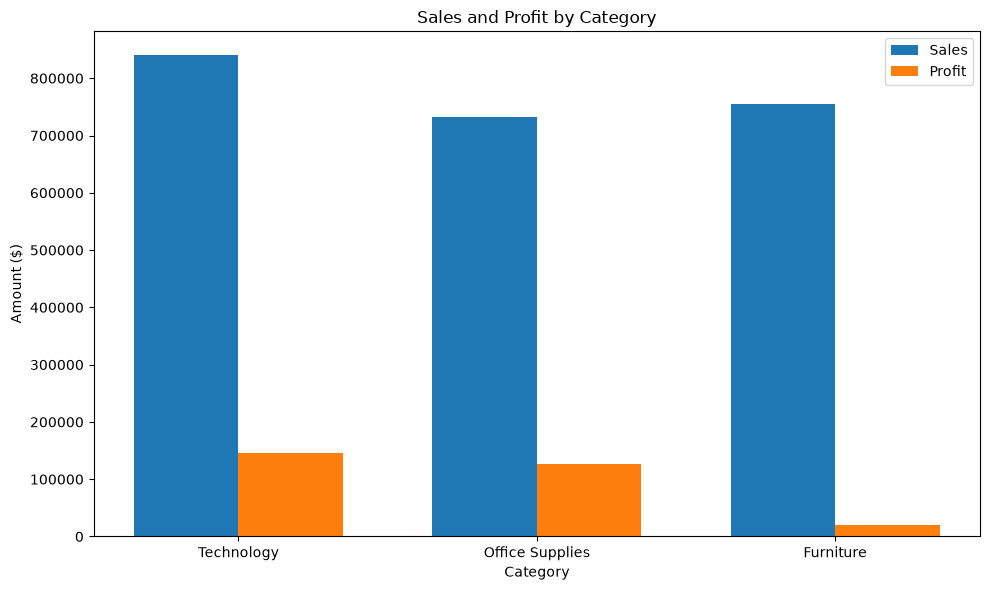

In [81]:
category_plot = category_analysis.sort_values("Profit", ascending=False)

plt.figure(figsize=(10, 6))

x = np.arange(len(category_plot))
width = 0.35

plt.bar(x - width/2, category_plot["Sales"], width, label="Sales")
plt.bar(x + width/2, category_plot["Profit"], width, label="Profit")

plt.xticks(x, category_plot["Category"])
plt.ylabel("Amount ($)")
plt.xlabel("Category")
plt.title("Sales and Profit by Category")
plt.legend()

plt.tight_layout()
plt.show()

### Visual Finding

Technology generated the highest profit among the three categories,
while Furniture generated substantial sales but comparatively little
profit.

The large difference between Furniture's sales and profit highlights
the category as a key area for profitability improvement.

# 9. Furniture Profitability Analysis

Furniture has a substantially lower profit margin than the other
categories.

The Furniture category is therefore analysed at the sub-category level
to identify which products are contributing to the weak profitability.

In [82]:
furniture_subcategory = (
    df[df["Category"] == "Furniture"]
    .groupby("Sub-Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
)

furniture_subcategory["Profit Margin"] = (
    furniture_subcategory["Profit"] /
    furniture_subcategory["Sales"]
) * 100

furniture_subcategory.sort_values(
    "Profit",
    ascending=False
)

,Sub-Category,Sales,Profit,Quantity,Orders,Profit Margin
1,Chairs,335768.2490,27223.5323,2431,591,8.107834
2,Furnishings,95598.1260,13891.7430,3799,919,14.531397
0,Bookcases,115361.2043,-3632.0736,878,228,-3.148436
3,Tables,208020.1820,-17753.2061,1261,314,-8.534367


### Furniture Sub-Category Findings

Profitability varies considerably across Furniture sub-categories.

- **Chairs:** 8.11% profit margin
- **Furnishings:** 14.53% profit margin
- **Bookcases:** -3.15% profit margin
- **Tables:** -8.53% profit margin

Tables and Bookcases are loss-making and appear to be the primary
contributors to Furniture's weak overall profitability.

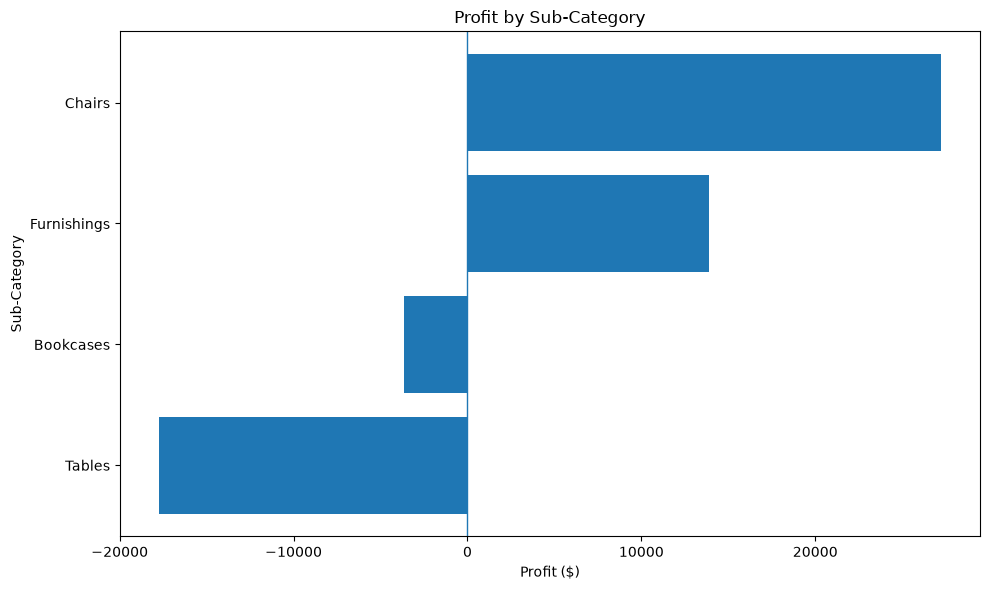

In [83]:
subcategory_plot = furniture_subcategory.sort_values("Profit")

plt.figure(figsize=(10, 6))

plt.barh(
    subcategory_plot["Sub-Category"],
    subcategory_plot["Profit"]
)

plt.xlabel("Profit ($)")
plt.ylabel("Sub-Category")
plt.title("Profit by Sub-Category")

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

### Visual Finding

Chairs generated the highest profit among the Furniture sub-categories,
while Tables recorded the largest loss.

Bookcases also generated a negative profit, indicating that Furniture's
overall weak profitability is concentrated in specific sub-categories.

Tables should therefore be investigated further, particularly in
relation to discounting and regional performance.

# 10. Discount and Profitability Analysis

The relationship between discount levels and profitability is
investigated to determine whether higher discounts are associated with
lower profits.

Both correlation analysis and aggregated discount-level profitability
are examined.

In [84]:
furniture_discount = (
    df[df["Category"] == "Furniture"]
    .groupby("Sub-Category")
    .agg(
        Average_Discount=("Discount", "mean"),
        Maximum_Discount=("Discount", "max"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

furniture_discount

,Sub-Category,Average_Discount,Maximum_Discount,Sales,Profit
0,Bookcases,0.215259,0.7,115361.2043,-3632.0736
1,Chairs,0.169243,0.3,335768.2490,27223.5323
2,Furnishings,0.138057,0.6,95598.1260,13891.7430
3,Tables,0.258129,0.5,208020.1820,-17753.2061


In [85]:
df[df["Category"] == "Furniture"][
    ["Sub-Category", "Discount", "Sales", "Profit"]
].corr(numeric_only=True)

,Discount,Sales,Profit
Discount,1.000000,-0.025282,-0.478204
Sales,-0.025282,1.000000,0.174342
Profit,-0.478204,0.174342,1.000000


### Correlation Finding

The correlation between Discount and Profit for Furniture is
approximately **-0.48**, indicating a moderate negative relationship.

This suggests that higher discount levels tend to be associated with
lower profits in the Furniture transactions.

However, correlation alone does not establish causation, so the
relationship is investigated further using discount-level
profitability analysis.

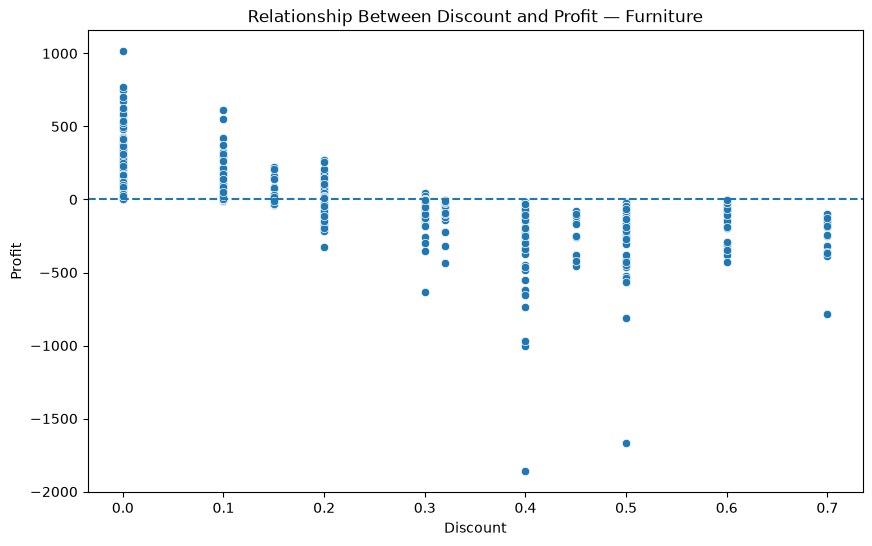

In [86]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df[df["Category"] == "Furniture"],
    x="Discount",
    y="Profit"
)

plt.title("Relationship Between Discount and Profit — Furniture")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.axhline(0, linestyle="--")

plt.show()

### Visual Interpretation

The scatter plot provides a visual representation of the negative
relationship between discount and profit.

As discount levels increase, profit generally tends to decline,
although there is considerable variation between individual
transactions.

In [87]:
discount_profit = (
    df[df["Category"] == "Furniture"]
    .groupby("Discount")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
)

discount_profit["Profit Margin"] = (
    discount_profit["Profit"] /
    discount_profit["Sales"]
) * 100

discount_profit

,Discount,Sales,Profit,Orders,Profit Margin
0,0.00,260155.0600,59476.9872,771,22.862130
1,0.10,47217.3930,7181.8049,73,15.210083
2,0.15,27558.5215,1418.9915,51,5.149012
3,0.20,223393.3480,6608.4977,559,2.958234
4,0.30,100191.1800,-10786.8269,209,-10.766244
5,0.32,14493.4588,-2391.1377,27,-16.498047
6,0.40,45614.4060,-16187.3968,72,-35.487466
7,0.45,5484.9740,-2493.1111,10,-45.453472
8,0.50,20983.4700,-12871.1990,53,-61.339707
9,0.60,7051.9800,-6134.0712,136,-86.983673


### Discount-Level Findings

Furniture profitability declines substantially as discount levels
increase.

At a 0% discount, Furniture transactions generated a profit margin of
approximately **22.86%**.

At a 30% discount, the aggregated profit margin became negative at
approximately **-10.77%**.

Higher discount levels were associated with increasingly negative
profit margins.

These results indicate that discounting is an important area for
further investigation.

In [88]:
discount_subcategory = (
    df[df["Category"] == "Furniture"]
    .groupby(["Sub-Category", "Discount"])
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
)

discount_subcategory["Profit Margin"] = (
    discount_subcategory["Profit"] /
    discount_subcategory["Sales"]
) * 100

discount_subcategory

,Sub-Category,Discount,Sales,Profit,Orders,Profit Margin
0,Bookcases,0.00,31935.9800,6075.7117,60,19.024660
1,Bookcases,0.15,27558.5215,1418.9915,51,5.149012
2,Bookcases,0.20,27178.1160,168.5882,46,0.620309
3,Bookcases,0.30,4282.6980,-555.8726,9,-12.979496
4,Bookcases,0.32,14493.4588,-2391.1377,27,-16.498047
5,Bookcases,0.50,7308.4600,-4255.8117,18,-58.231306
6,Bookcases,0.70,2603.9700,-4092.5430,17,-157.165520
7,Chairs,0.00,92276.3700,22314.4783,129,24.182224
8,Chairs,0.10,46855.6290,7113.4717,72,15.181680
9,Chairs,0.20,126630.7480,4532.6990,243,3.579462


# 11. Regional Performance Analysis

Sales and profitability are compared across the four regions to
identify geographic differences in business performance.

In [89]:
region_analysis = (
    df.groupby("Region")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
)

region_analysis["Profit Margin"] = (
    region_analysis["Profit"] /
    region_analysis["Sales"]
) * 100

region_analysis.sort_values("Profit", ascending=False)

,Region,Sales,Profit,Quantity,Orders,Profit Margin
3,West,739813.6085,110798.8170,12466,1635,14.976585
1,East,691828.1680,94883.2603,11159,1475,13.714859
2,South,391721.9050,46749.4303,6209,822,11.934342
0,Central,503170.6728,39865.3070,8820,1179,7.922820


### Regional Findings

The **West** region has the highest overall profit margin at
approximately **14.98%**.

The **Central** region has the lowest overall profit margin at
approximately **7.92%**.

This indicates that regional performance varies considerably and
warrants further investigation.

In [90]:
furniture_region = (
    df[df["Category"] == "Furniture"]
    .groupby("Region")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
        Average_Discount=("Discount", "mean")
    )
    .reset_index()
)

furniture_region["Profit Margin"] = (
    furniture_region["Profit"] /
    furniture_region["Sales"]
) * 100

furniture_region.sort_values("Profit", ascending=False)

,Region,Sales,Profit,Orders,Average_Discount,Profit Margin
3,West,260679.7295,12316.2514,613,0.130476,4.724668
2,South,117298.6840,6771.2061,278,0.121536,5.772619
1,East,212231.6960,3444.7448,521,0.154391,1.623106
0,Central,164537.6518,-2802.2067,407,0.297402,-1.703079


### Furniture Profitability by Region

The profitability of Furniture varies considerably across the four
regions.

Profit margin is visualised to compare regional performance and identify
regions where Furniture may require further investigation.

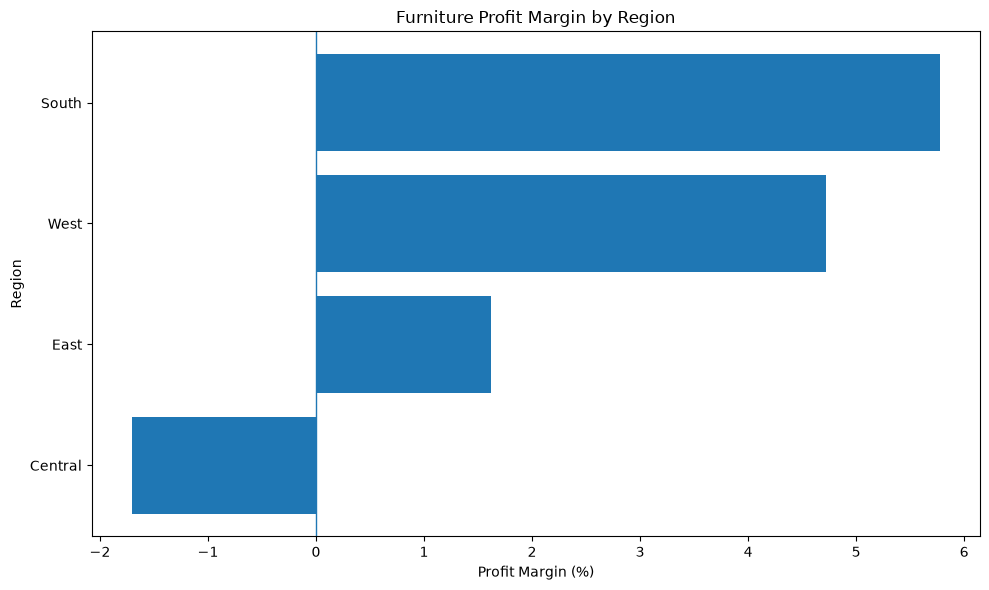

In [91]:
region_plot = furniture_region.sort_values("Profit Margin")

plt.figure(figsize=(10, 6))

plt.barh(
    region_plot["Region"],
    region_plot["Profit Margin"]
)

plt.xlabel("Profit Margin (%)")
plt.ylabel("Region")
plt.title("Furniture Profit Margin by Region")

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

### Visual Finding

The South region has the highest Furniture profit margin at
approximately **5.77%**, while the West generates the highest
absolute Furniture profit at approximately **$12.32K**.

The East has a considerably lower profit margin of approximately
**1.62%**, while Central is the only region with a negative Furniture
profit margin at approximately **-1.70%**.

Central therefore represents the weakest regional performance and
requires further investigation into factors such as discounting,
sub-category mix and pricing.

## 12. Central Region Furniture Investigation

Because Central has the lowest overall regional profit margin and
Furniture is the weakest-performing category, Furniture performance in
the Central region is investigated further.

In [92]:
central_furniture = (
    df[
        (df["Category"] == "Furniture") &
        (df["Region"] == "Central")
    ]
    .groupby("Sub-Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
        Average_Discount=("Discount", "mean")
    )
    .reset_index()
)

central_furniture["Profit Margin"] = (
    central_furniture["Profit"] /
    central_furniture["Sales"]
) * 100

central_furniture.sort_values("Profit", ascending=False)

,Sub-Category,Sales,Profit,Orders,Average_Discount,Profit Margin
1,Chairs,85941.1420,6670.8633,146,0.192949,7.762130
0,Bookcases,24157.1768,-1997.9043,49,0.232800,-8.270438
3,Tables,39154.9710,-3559.6504,68,0.262500,-9.091184
2,Furnishings,15284.3620,-3915.5153,193,0.403865,-25.617787


### Central Furniture Findings

Furniture in the Central region has a negative profit margin of
approximately **-1.70%** and an average discount of approximately
**29.74%**.

Within Central Furniture:

- Chairs generate a positive **7.76%** margin.
- Bookcases generate a negative **-8.27%** margin.
- Tables generate a negative **-9.09%** margin.
- Furnishings generate the lowest margin at **-25.62%**.

The results indicate that the profitability problem is concentrated
within specific sub-categories rather than across all Furniture
products.

In [93]:
central_furniture_discount = (
    df[
        (df["Category"] == "Furniture") &
        (df["Region"] == "Central")
    ]
    .groupby("Discount")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
    .sort_values("Discount")
)

central_furniture_discount["Profit Margin"] = (
    central_furniture_discount["Profit"] /
    central_furniture_discount["Sales"]
) * 100

central_furniture_discount

,Discount,Sales,Profit,Orders,Profit Margin
0,0.00,74929.3500,16641.3819,130,22.209430
1,0.20,726.4880,75.1427,3,10.343282
2,0.30,61178.9850,-6866.8937,133,-11.224269
3,0.32,14493.4588,-2391.1377,27,-16.498047
4,0.50,6550.6700,-4309.7447,17,-65.790899
5,0.60,6658.7000,-5950.9552,128,-89.371126


### Central Furniture Discount Findings

Profitability deteriorates substantially at higher discount levels in
Central Furniture.

At a 0% discount, the aggregated profit margin is approximately
**22.21%**.

At a 30% discount, the margin falls to approximately **-11.22%**.

At a 60% discount, the margin falls further to approximately
**-89.37%**.

These results show a strong association between high discount levels
and poor profitability in Central Furniture.

However, the analysis does not establish that discounts alone cause
the losses. Other factors such as product mix, pricing and regional
characteristics may also contribute.

# 13. Time-Series Analysis

Sales and profit are analysed over time to identify trends and changes
in business performance.

Understanding how performance changes over time can help determine
whether the business is experiencing sustained growth, declining
profitability or fluctuations in performance.

In [94]:
yearly_analysis = (
    df.groupby(df["Order Date"].dt.year)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
)

yearly_analysis

,Order Date,Sales,Profit,Orders
0,2023,494040.2121,51684.2957,995
1,2024,472993.0310,62020.9695,1053
2,2025,613933.5800,82665.2018,1340
3,2026,745567.5312,95926.3476,1723


### Annual Performance Findings

The business shows an overall upward trend in both sales and profit
between 2023 and 2026.

Sales increased from approximately **$494.0K in 2023** to
**$745.6K in 2026**, while profit increased from approximately
**$51.7K to $95.9K** over the same period.

The number of orders also increased consistently, from **995 orders
in 2023** to **1,723 orders in 2026**.

Although sales declined slightly in 2024 compared with 2023, profit
increased during the same period. From 2025 onwards, both sales and
profit increased substantially, indicating strong overall business
growth.

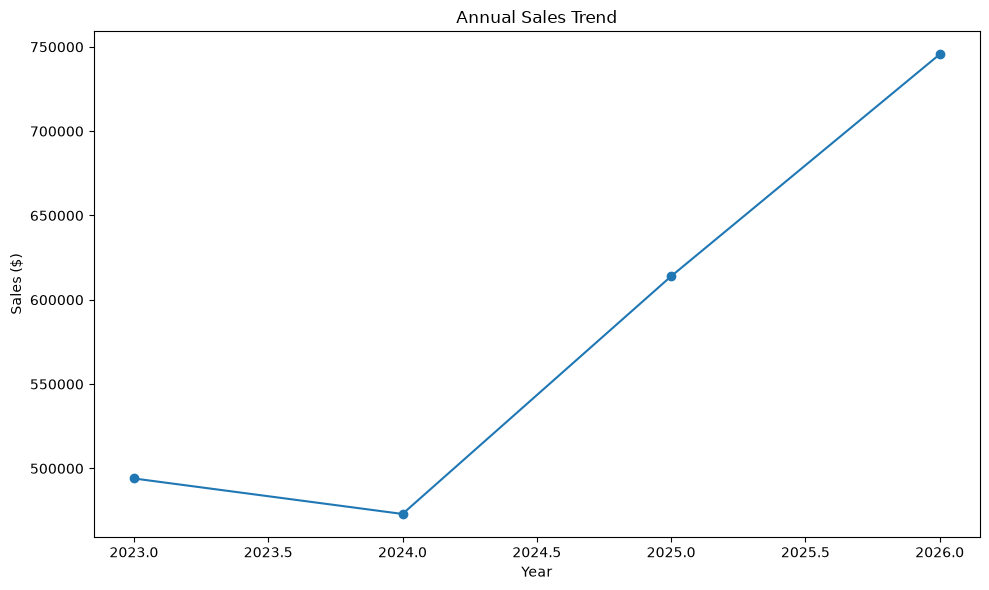

In [95]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_analysis["Order Date"],
    yearly_analysis["Sales"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Sales ($)")
plt.title("Annual Sales Trend")

plt.tight_layout()
plt.show()

### Sales Trend Findings

Sales remained relatively stable between 2023 and 2024, with a slight
decline from approximately **$494.0K** to **473.0K**.

From 2025 onwards, sales increased substantially, reaching approximately
**$613.9K in 2025** and **745.6K in 2026**.

Overall, the business demonstrates **strong sales growth** towards the end
of the period, with 2026 recording the highest annual sales.

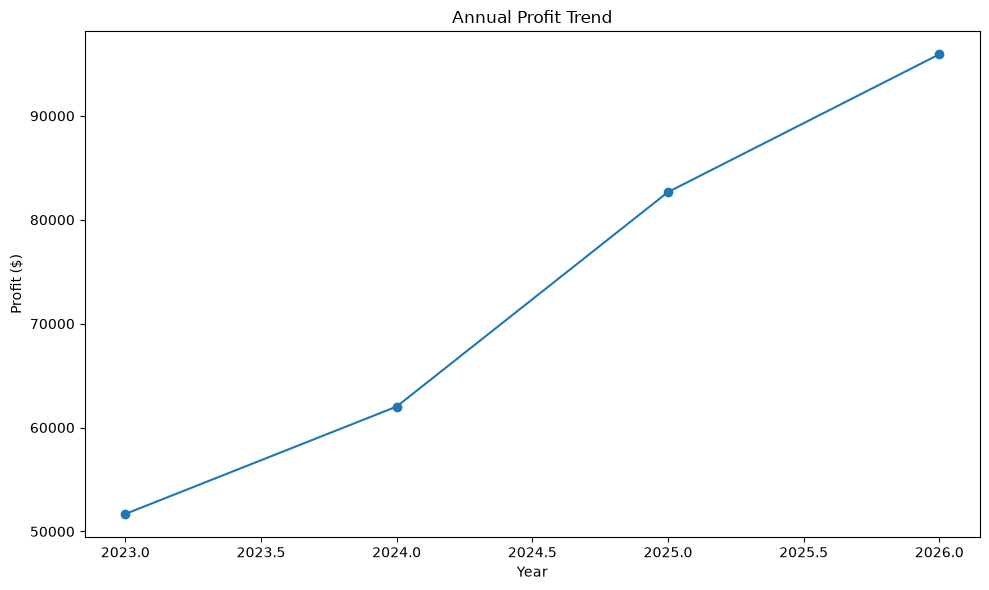

In [96]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_analysis["Order Date"],
    yearly_analysis["Profit"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Profit ($)")
plt.title("Annual Profit Trend")

plt.tight_layout()
plt.show()

### Profit Trend

Profit increased consistently across the period, despite the slight
decline in sales in 2024.

Profit rose from approximately **$51.7K in 2023** to
**95.9K in 2026**, indicating an overall improvement in
profit generation alongside business growth.

# 14. Key Findings & Business Recommendations

After going through the data and the different analyses, these are the
main findings I found:

1. The business generated around **$2.33M in sales** and **$292K in
   profit**, giving an overall profit margin of **12.56%**.

2. **Technology** performed the best among the three categories, with a
   profit margin of **17.45%**.

3. **Furniture** had fairly high sales, but its profit margin was only
   **2.61%**, which makes it the category that needs the most attention.

4. Within Furniture, **Tables and Bookcases** were the main
   loss-making sub-categories.

5. For Furniture, discount and profit showed a moderate negative
   correlation of around **-0.48**. This suggests that higher discounts
   are generally associated with lower profits.

6. Among the regions, **Central** had the lowest overall profit margin
   at **7.92%**.

7. The situation is more concerning for Furniture in Central, where the
   profit margin was **-1.70%** and the average discount was around
   **29.74%**.

8. Looking at the different discount levels, higher discounts were
   generally linked with much lower profitability, especially for
   Furniture in the Central region.

## Business Recommendations

Based on what I found, I would focus on a few areas:

- **Review high discounts on Furniture**, especially when they are
  resulting in negative profits.
- **Look more closely at Tables and Bookcases** to identify which
  products are consistently making losses.
- **Continue focusing on Technology and Office Supplies**, since both
  categories have much stronger profit margins.
- **Investigate Furniture sales in the Central region** to understand
  why relatively high discounts are still resulting in losses.
- When evaluating performance, look at **both sales and profit** rather
  than sales alone, since high sales do not necessarily mean high
  profitability.

## Overall Conclusion

Overall, the business is showing a positive trend. Sales, orders and
profit have increased over the years, which is a good sign for the
business.

At the same time, the analysis shows that performance is not the same
across all categories, sub-categories and regions. **Furniture,
especially Tables and Bookcases, stands out as the main area that needs
attention.**

The discount analysis also suggests that controlling discounts and
looking more closely at product-level profitability could help improve
profits while still maintaining the overall growth of the business.